In [ ]:
!pip install sdv

import pandas as pd
from google.colab import drive


# Load the dataset
real_data = pd.read_csv('health_disease_prediction.csv')
real_data.head(100000)
#data cleaning
real_data = real_data.drop_duplicates()
real_data = real_data.dropna()

# Label encode categorical columns including the target
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
real_data['Disease'] = label_encoder.fit_transform(real_data['Disease'])


# metadata
from sdv.metadata import Metadata
metadata = Metadata.detect_from_dataframe(
    data=real_data,
    table_name='health_disease_prediction'
)

# Train TVAE Synthesizer
from sdv.single_table import TVAESynthesizer
synthesizer = TVAESynthesizer(metadata)
synthesizer.fit(real_data)

#generate synthetic data
synthetic_data = synthesizer.sample(num_rows=1500)

# split features & goal
X_synthetic = synthetic_data.drop(['Disease'], axis=1)
y_synthetic = synthetic_data['Disease']

X_real = real_data.drop(['Disease'], axis=1)
y_real = real_data['Disease']

# Train-test split
from sklearn.model_selection import train_test_split
X_train_synthetic, X_test_synthetic, y_train_synthetic, y_test_synthetic = train_test_split(X_synthetic, y_synthetic, test_size=0.3, random_state=42)
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size=0.3, random_state=42)

# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_real = scaler.fit_transform(X_train_real)
X_test_real = scaler.transform(X_test_real)
X_train_synthetic = scaler.transform(X_train_synthetic)
X_test_synthetic = scaler.transform(X_test_synthetic)

# KNN Model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_synthetic, y_train_synthetic)

# Predict on real test data
y_pred_knn = knn_model.predict(X_test_real)

# Evaluation
print("\nKNN Classifier Results:")
print(f"Accuracy: {accuracy_score(y_test_real, y_pred_knn):.2f}")
print(f"Precision: {precision_score(y_test_real, y_pred_knn, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test_real, y_pred_knn, average='weighted'):.2f}")
print(f"F1 Score: {f1_score(y_test_real, y_pred_knn, average='weighted'):.2f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.1/198.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 5.9 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/sdv/single_table/base.py:129: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


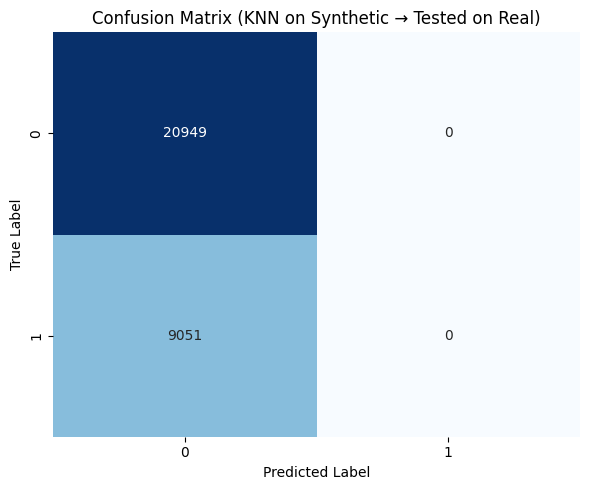

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-3-255777710.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_names, y=metrics, palette='Set2')


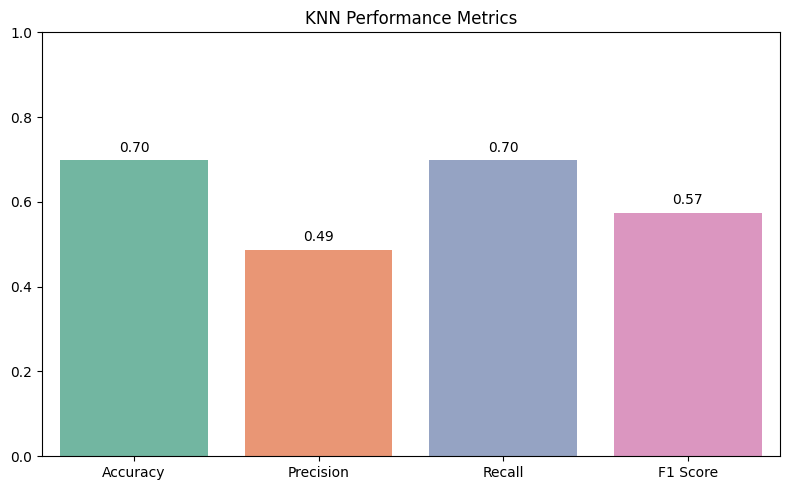

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

#Confusion Matrix Plot
cm = confusion_matrix(y_test_real, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (KNN on Synthetic → Tested on Real)')
plt.tight_layout()
plt.show()


#bar plot of evaluation matrix
accuracy = accuracy_score(y_test_real, y_pred_knn)
precision = precision_score(y_test_real, y_pred_knn, average='weighted')
recall = recall_score(y_test_real, y_pred_knn, average='weighted')
f1 = f1_score(y_test_real, y_pred_knn, average='weighted')

metrics = [accuracy, precision, recall, f1]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(8, 5))
sns.barplot(x=metric_names, y=metrics, palette='Set2')
plt.ylim(0, 1)
plt.title('KNN Performance Metrics')
for i, val in enumerate(metrics):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center')
plt.tight_layout()
plt.show()


##Tuning the KNN

In [ ]:
import matplotlib.pyplot as plt

# Define parameter grid
neighbors = [3, 5, 7, 9]
metrics = ['euclidean', 'manhattan', 'minkowski']

# Store results
results = []

print("Tuning KNN with different neighbors and distance metrics \n")

# Iteration
for k in neighbors:
    for metric in metrics:
        knn_model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn_model.fit(X_train_synthetic, y_train_synthetic)
        y_pred = knn_model.predict(X_test_real)

        acc = accuracy_score(y_test_real, y_pred)
        prec = precision_score(y_test_real, y_pred, average='weighted')
        rec = recall_score(y_test_real, y_pred, average='weighted')
        f1 = f1_score(y_test_real, y_pred, average='weighted')

        print(f"k={k}, metric={metric} → Acc: {acc:.2f}, Prec: {prec:.2f}, Rec: {rec:.2f}, F1: {f1:.2f}")
        results.append({'k': k, 'metric': metric, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1})


Tuning KNN with different neighbors and distance metrics 

k=3, metric=euclidean → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57
k=3, metric=manhattan → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57
k=3, metric=minkowski → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

k=5, metric=euclidean → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57
k=5, metric=manhattan → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57
k=5, metric=minkowski → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


k=7, metric=euclidean → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57
k=7, metric=manhattan → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57
k=7, metric=minkowski → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


k=9, metric=euclidean → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57
k=9, metric=manhattan → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57
k=9, metric=minkowski → Acc: 0.70, Prec: 0.49, Rec: 0.70, F1: 0.57


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Real-to-Real KNN Baseline for comparison with TSRT
Evaluating the KNN model on real data to establish baseline for comparison with TSTR output


 Real to Real KNN Results:
Accuracy: 0.64
Precision: 0.58
Recall: 0.64
F1 score: 0.60


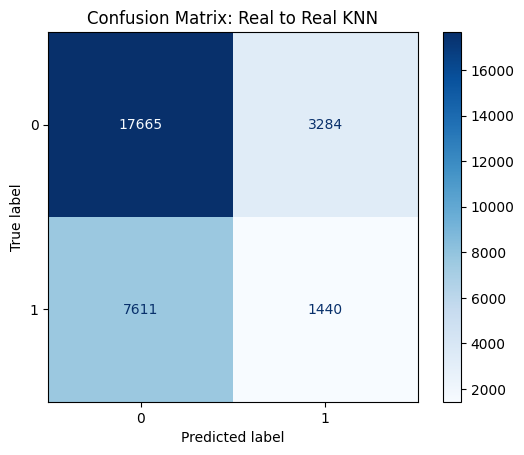

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


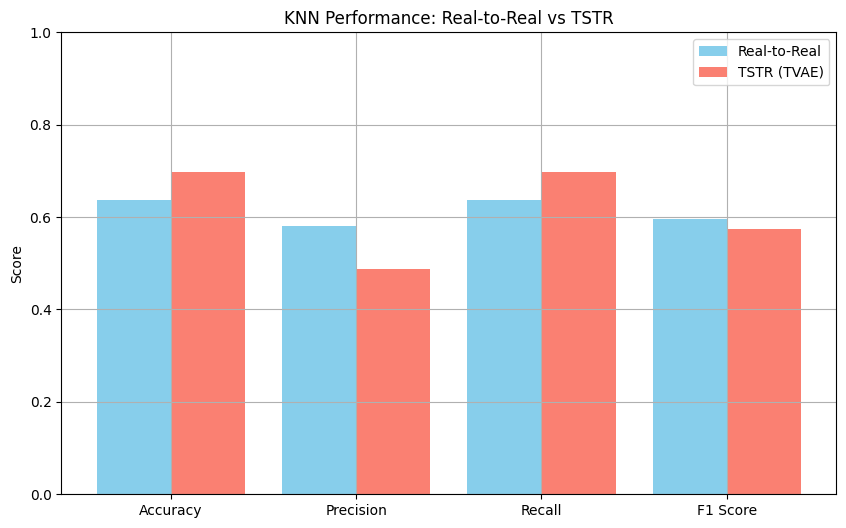

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#train KNN on real-to-real data
knn_real = KNeighborsClassifier(n_neighbors=5)
knn_real.fit(X_train_real, y_train_real)

#predict on real_data
y_pred_real = knn_real.predict(X_test_real)
#Evaluation
real_accuracy = accuracy_score(y_test_real, y_pred_real)
real_precision = precision_score(y_test_real, y_pred_real, average='weighted')
real_recall = recall_score(y_test_real, y_pred_real, average='weighted')
real_f1 = f1_score(y_test_real, y_pred_real, average='weighted')

print("\n Real to Real KNN Results:")
print(f"Accuracy: {real_accuracy:.2f}")
print(f"Precision: {real_precision:.2f}")
print(f"Recall: {real_recall:.2f}")
print(f"F1 score: {real_f1:.2f}")
# Confusion Matrix
cm = confusion_matrix(y_test_real, y_pred_real)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Real to Real KNN")
plt.show()


# compare with the tstr  results
tstr_accuracy = accuracy_score(y_test_real, y_pred_knn)
tstr_precision = precision_score(y_test_real, y_pred_knn, average='weighted')
tstr_recall = recall_score(y_test_real, y_pred_knn, average='weighted')
tstr_f1 = f1_score(y_test_real, y_pred_knn, average='weighted')

# Bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
tstr_scores = [tstr_accuracy, tstr_precision, tstr_recall, tstr_f1]
real_scores = [real_accuracy, real_precision, real_recall, real_f1]

x = range(len(metrics))
plt.figure(figsize=(10,6))
plt.bar(x, real_scores, width=0.4, label='Real-to-Real', align='center', color='skyblue')
plt.bar([p + 0.4 for p in x], tstr_scores, width=0.4, label='TSTR (TVAE)', align='center', color='salmon')
plt.xticks([p + 0.2 for p in x], metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("KNN Performance: Real-to-Real vs TSTR")
plt.legend()
plt.grid(True)
plt.show()



#Error Analysis
Analyzing the confusion matrix & error patterns of TSTR KNN predictions to identify which classes or instances are most frequently misclassified


Misclassified Examples (first 5):
Sample 3 → Predicted: 0, Actual: 1
Sample 7 → Predicted: 0, Actual: 1
Sample 8 → Predicted: 0, Actual: 1
Sample 18 → Predicted: 0, Actual: 1
Sample 19 → Predicted: 0, Actual: 1


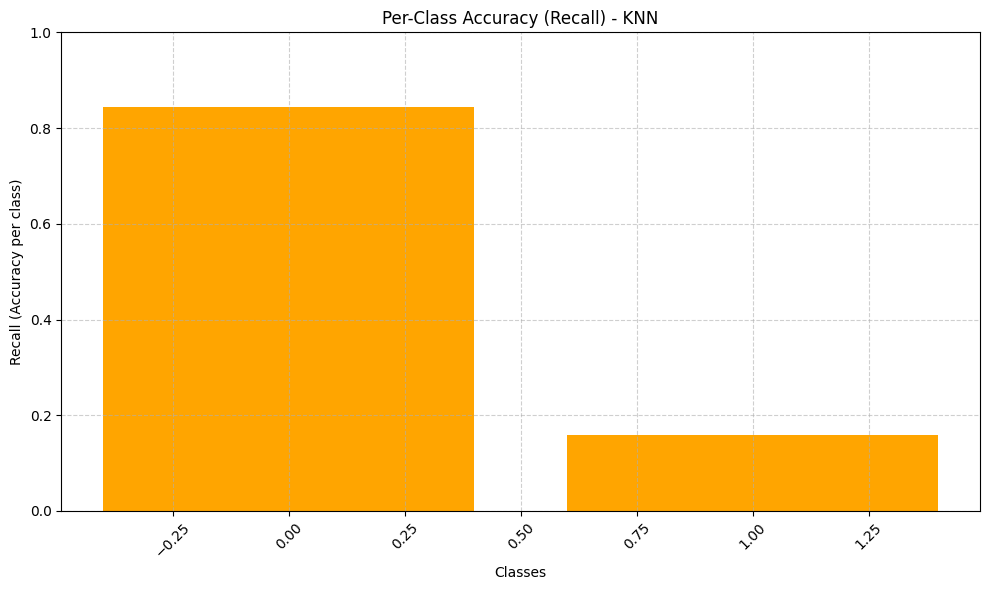

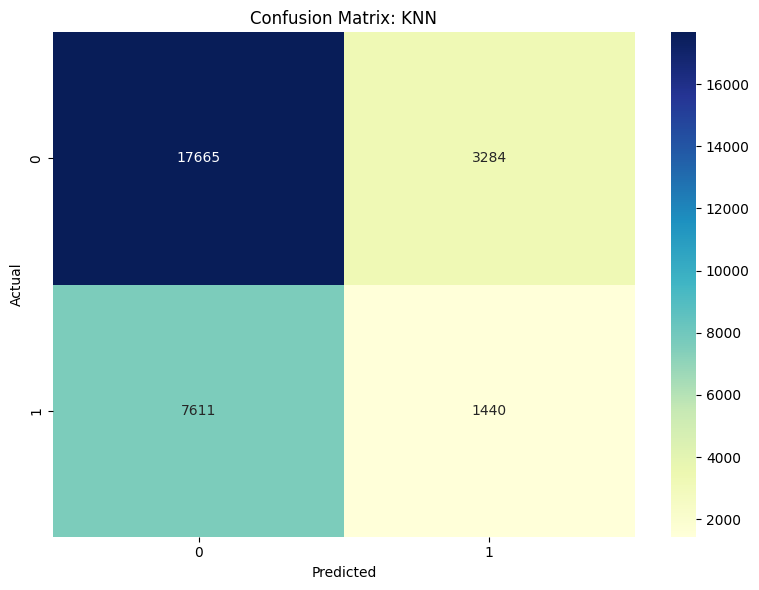

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

data_path = 'health_disease_prediction.csv'
real_data = pd.read_csv(data_path)

# 1. Preprocess
real_data = real_data.drop_duplicates().dropna()
label_encoder = LabelEncoder()
real_data['Disease'] = label_encoder.fit_transform(real_data['Disease'])
X = real_data.drop(['Disease'], axis=1)
y = real_data['Disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train on real_data (Real to Real baseline)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

#2. Extract misclassified index
misclassified_idx = np.where(y_test.values != y_pred_knn)[0]

print("\nMisclassified Examples (first 5):")
for i in misclassified_idx[:5]:
    print(f"Sample {i} → Predicted: {y_pred_knn[i]}, Actual: {y_test.values[i]}")

#3. Per-class accuracy
report = classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_, output_dict=True)
classes = list(report.keys())[:-3]
recalls = [report[cls]['recall'] for cls in classes]

plt.figure(figsize=(10, 6))
plt.bar(classes, recalls, color='orange')
plt.title("Per-Class Accuracy (Recall) - KNN")
plt.xlabel("Classes")
plt.ylabel("Recall (Accuracy per class)")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#Enhancing Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: KNN")
plt.tight_layout()
plt.show()
